# Lab 6 — Dynamic 3D / 4D Worlds：给点云加上时间轴

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab06_dynamic_4d_worlds/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 6 · Spatial 线**

Lab 0–3 在 2D 图像与低维状态上学 world model；空间线的模块 03–04 讲了**静态** 3D 表示（点云、NeRF、3D Gaussian Splatting）。但真实世界是动的——人会走、车会开、手会抓。静态表示在动态场景面前有一个根本缺陷：它回答不了**"下一秒在哪里"**。

本实验把 3D 表示加上时间轴，即 **4D = 3D + time**。我们不做大型的 4D reconstruction，而是在代码内生成一个迷你动态场景——三个做不同运动的点云物体（刚性旋转平移的 cube、匀速圆周的 sphere、呼吸形变的 blob），带噪声观测——然后完成四件事：

```
带噪点云序列 (x, y, z) × T 帧
        │
        ├─ ① Motion estimation   centroid tracking + ICP-style 配准 → scene flow（逐点运动场）
        ├─ ② Temporal interpolation   x(t+α) = x(t) + α · flow，在两帧之间"无中生有"
        └─ ③ Dynamics learning   MLP: (p_t, v_t) → Δp，外推未来 10 帧 ← world model 的 prediction 在 3D 空间的形态
```

教学落点：**4D 表示是 spatial world model 的动态扩展**；你将亲眼看到静态 (x, y, z) 表示丢掉的信息，正是预测未来所必需的信息。

## 1. Motivation — 静态 3D 回答不了"下一秒在哪里"

一张点云 $(x, y, z)$ 是一张**快照**：它告诉你世界的几何在某个时刻长什么样，却没有索引时间的维度。给它配上时间戳与逐帧对应关系，得到 $(x, y, z, t)$，表示才真正成为一个**状态随时间演化的世界模型**。

区别不是形式上的多一个坐标，而是能力上的：

| 问题 | 静态 3D (x,y,z) | 动态 4D (x,y,z,t) |
|---|---|---|
| 这个物体是什么形状？ | ✅ | ✅ |
| 它现在在往哪走？ | ❌（没有速度） | ✅ |
| 两帧之间发生了什么？ | ❌ | ✅（temporal interpolation） |
| 5 秒后它在哪里？ | ❌ | ✅（dynamics 外推） |

自动驾驶最关心的从来不是"这辆车长什么样"，而是"它 0.5 秒后会不会进入我的车道"。本实验的四个核心内容，正好对应从快照到预测的完整链条：**估计运动 → 插值过去 → 拟合动力学 → 外推未来**。

## 2. Setup

**Why:** 唯一重的依赖是 PyTorch（CPU 版足够，Colab 已预装）；`imageio` 用来把逐帧 3D scatter 存成 GIF，`matplotlib` 负责 3D 可视化。首格自动检测 Colab 环境并补装缺失包，整个实验在 CPU 上几分钟内跑完。

In [1]:
# @title setup
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio"), ("matplotlib", "matplotlib")]:
    ensure(pkg, name)

import io
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import imageio.v2 as imageio

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
rng = np.random.default_rng(0)
T_CLOCK = time.time()   # 全程计时
print("torch", torch.__version__, "| device: cpu | colab:", IN_COLAB)


torch 2.8.0 | device: cpu | colab: False


## 3. Environment & Dataset — 一个迷你动态 3D 场景

**Why:** 要研究动态表示，先要有一个"我们知道全部真相"的动态世界。我们在代码内生成 $T = 60$ 帧、每帧 3 个物体的点云，三种运动各有教学分工：

- **cube**：刚性运动——匀速平移 + 绕 $z$ 轴匀速旋转。它是 constant-velocity 模型的主场，也是 ICP 配准的测试对象。
- **sphere**：匀速**圆周**运动——有持续加速度，恒速外推必然失败，是 learned dynamics 的展示台。
- **blob**：上下浮动（正弦）+ **呼吸式非刚性形变**（尺度脉动）——刚性假设在这里失效。

观测模型：每帧对真实点云加 Gaussian noise（$\sigma = 0.02$），模拟深度相机的测量误差。物体分割（哪个点属于哪个物体）假设已知——真实系统里这一步由 3D detector / tracker 给出，不是本实验的重点。

**关键设计**：三个物体的质心运动都满足 Markov 性——下一帧位移 $\Delta p$ 是当前状态 $(p, v)$ 的确定性函数。这保证了 Section 5 的 dynamics model 在原理上可学。

In [2]:
T, N_PTS, NOISE_STD = 60, 150, 0.02

def sphere_pts(n, r, rng):
    v = rng.normal(size=(n, 3))
    return r * v / np.linalg.norm(v, axis=1, keepdims=True)

# canonical space：每个物体的"标准形状"，之后所有时刻的世界点云都由它变换而来
CANON = {
    "cube":   rng.uniform(-0.35, 0.35, size=(N_PTS, 3)),
    "sphere": sphere_pts(N_PTS, 0.30, rng),
    "blob":   sphere_pts(N_PTS, 0.28, rng),
}

# 运动参数
OMEGA_CUBE = 0.06                                   # cube 每步绕 z 旋转 (rad)
V_CUBE = np.array([0.030, 0.020, 0.010])            # cube 每步平移
P0_CUBE = np.array([-1.0, -0.2, 0.0])
OMEGA_SPH, R_ORB, Z_ORB = 0.15, 0.8, 0.5            # sphere 圆周：角速度 / 半径 / 高度
BLOB_CENTER = np.array([0.9, -0.6, 0.0])
BLOB_AMP, BLOB_OMEGA = 0.25, 0.3                    # blob 质心 z 向正弦：幅度 / 角速度
BREATH_AMP, BREATH_OMEGA = 0.3, 0.35                # blob 非刚性呼吸：幅度 / 角速度

def Rz(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])

def cube_pose(t):   return P0_CUBE + V_CUBE * t, Rz(OMEGA_CUBE * t)
def sphere_c(t):    return np.array([R_ORB * np.cos(OMEGA_SPH * t), R_ORB * np.sin(OMEGA_SPH * t), Z_ORB])
def blob_c(t):      return BLOB_CENTER + np.array([0.0, 0.0, 0.3 + BLOB_AMP * np.sin(BLOB_OMEGA * t)])
def blob_scale(t):  return 1.0 + BREATH_AMP * np.sin(BREATH_OMEGA * t)

def world_frame(t):
    """ground-truth 世界点云（无噪声）"""
    p, R = cube_pose(t)
    return {
        "cube":   CANON["cube"] @ R.T + p,                    # 刚性：旋转 + 平移
        "sphere": CANON["sphere"] + sphere_c(t),              # 刚性：纯平移
        "blob":   CANON["blob"] * blob_scale(t) + blob_c(t),  # 非刚性：形变 + 平移
    }

gt_frames  = [world_frame(t) for t in range(T)]
obs_frames = [{k: v + rng.normal(0, NOISE_STD, size=v.shape) for k, v in f.items()}
              for f in gt_frames]
gt_centroids  = {k: np.stack([f[k].mean(0) for f in gt_frames])  for k in CANON}  # (T, 3)
est_centroids = {k: np.stack([f[k].mean(0) for f in obs_frames]) for k in CANON}

NAMES = list(CANON)
print(f"{T} frames × {len(NAMES)} objects × {N_PTS} points | noise σ = {NOISE_STD}")
print("centroid tracking error (noisy obs vs gt):",
      {k: round(float(np.linalg.norm(est_centroids[k] - gt_centroids[k], axis=1).mean()), 5) for k in NAMES})


60 frames × 3 objects × 150 points | noise σ = 0.02
centroid tracking error (noisy obs vs gt): {'cube': 0.00242, 'sphere': 0.00268, 'blob': 0.00249}


### 3.1 静态 (x, y, z) vs 动态 (x, y, z, t)：一眼看懂差在哪

同一个 cube，两种看法。左图是**静态表示**：第 20 帧的一堆点，形状完整，但没有任何"它将去哪"的信息。右图把 60 帧叠进 **spacetime**：x、y 轴是空间，纵轴是时间——点云拉成了一条**轨迹管 (trajectory tube)**。运动方向、速度、加速度全都写在管的形状里。

这就是 4D 表示的本质：不是多存了一个数，而是把"世界的历史"变成表示的一等公民。

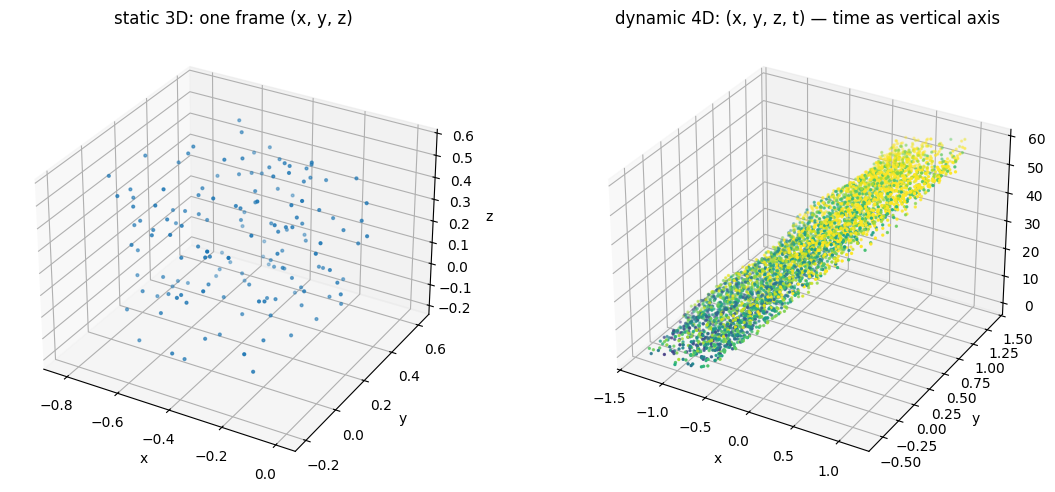

saved assets/static_vs_dynamic.png


In [3]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(121, projection="3d")
pts = obs_frames[20]["cube"]
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=4, c="#1f77b4")
ax.set_title("static 3D: one frame (x, y, z)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax = fig.add_subplot(122, projection="3d")
for t in range(0, T, 2):                      # 每 2 帧取一层，避免太密
    pts = obs_frames[t]["cube"]
    ax.scatter(pts[:, 0], pts[:, 1], np.full(len(pts), t), s=2, c=pts[:, 2],
               cmap="viridis", vmin=-0.5, vmax=0.5)
ax.set_title("dynamic 4D: (x, y, z, t) — time as vertical axis")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("t")

plt.tight_layout()
plt.savefig("assets/static_vs_dynamic.png", dpi=90, bbox_inches="tight")
plt.show()
print("saved assets/static_vs_dynamic.png")


## 4. Build the Model — 运动估计：centroid tracking + ICP-style 配准

**Why:** 预测未来之前，先要从相邻帧把"运动"读出来。两个粒度：

1. **Object-level — centroid tracking**：每个物体的质心均值是平移的稳健估计（上面已算好 `est_centroids`）。简单、抗噪，但丢掉了旋转与形变。
2. **Point-level — scene flow / ICP**：逐点运动场。我们用最近邻 (nearest-neighbor) 匹配建立帧间对应 $p_i \mapsto q_{\text{nn}(i)}$，得到 flow 向量；对刚性物体（cube），再迭代地 **最近邻匹配 + Kabsch 求解**（SVD 求最优旋转）恢复 $(R, t)$——这就是 ICP (Iterative Closest Point) 的核心循环，全部手写、不足 20 行。

最近邻匹配只在**帧间位移 < 点间距**时可靠，这是它的已知软肋（见 Section 9 思考题）。我们对 cube 跑 ICP，并用已知的 ground truth 相对位姿打分数。

ICP on cube, frames 10->11:
  rotation error : 1.33 deg  (gt per-step rotation = 3.44 deg)
  translation err: 0.0184  (gt step |v| = 0.0374)


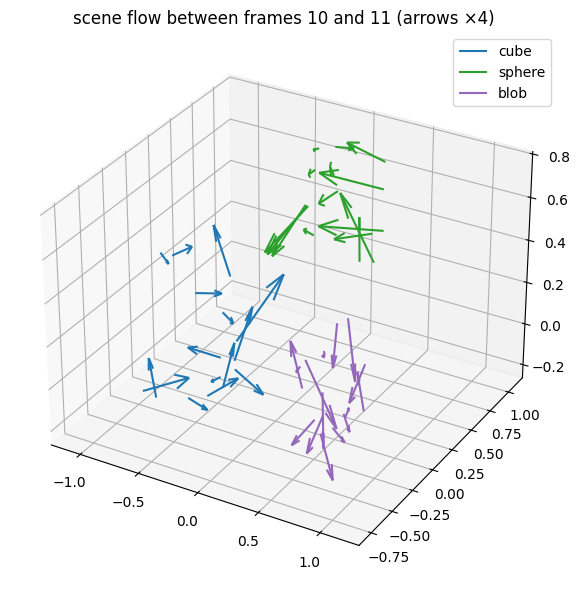

In [4]:
def nn_correspondences(P, Q):
    """对每个 p_i 找 Q 中最近点的索引"""
    d2 = ((P[:, None, :] - Q[None, :, :]) ** 2).sum(-1)
    return np.argmin(d2, axis=1)

def icp_rigid(P, Q, iters=5):
    """估计 R, t 使 Q ≈ P @ R.T + t：迭代 最近邻匹配 + Kabsch (SVD) 求解"""
    R, t = np.eye(3), np.zeros(3)
    for _ in range(iters):
        Pw = P @ R.T + t
        Qm = Q[nn_correspondences(Pw, Q)]
        pc, qc = Pw.mean(0), Qm.mean(0)
        U, _, Vt = np.linalg.svd((Pw - pc).T @ (Qm - qc))
        dR = Vt.T @ U.T
        if np.linalg.det(dR) < 0:          # 禁止反射
            Vt[-1] *= -1
            dR = Vt.T @ U.T
        R, t = dR @ R, dR @ t + (qc - pc @ dR.T)
    return R, t

def scene_flow(P, Q):
    """逐点运动场：flow_i = q_nn(i) - p_i"""
    return Q[nn_correspondences(P, Q)] - P

# --- 在 cube 的 (frame 10, frame 11) 上测试 ICP ---
t_pair = 10
R_hat, t_hat = icp_rigid(obs_frames[t_pair]["cube"], obs_frames[t_pair + 1]["cube"])

# ground truth 相对位姿：x_{t+1} = R_rel · x_t + t_rel
p0_, R0_ = cube_pose(t_pair)
p1_, R1_ = cube_pose(t_pair + 1)
R_rel = R1_ @ R0_.T
t_rel = p1_ - p0_ @ R_rel.T

angle_err = np.degrees(np.arccos(np.clip((np.trace(R_rel.T @ R_hat) - 1) / 2, -1, 1)))
print(f"ICP on cube, frames {t_pair}->{t_pair + 1}:")
print(f"  rotation error : {angle_err:.2f} deg  (gt per-step rotation = {np.degrees(OMEGA_CUBE):.2f} deg)")
print(f"  translation err: {np.linalg.norm(t_hat - t_rel):.4f}  (gt step |v| = {np.linalg.norm(V_CUBE):.4f})")

# --- scene flow 可视化 ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
COLORS = {"cube": "#1f77b4", "sphere": "#2ca02c", "blob": "#9467bd"}
for k in NAMES:
    P = obs_frames[t_pair][k]
    F = scene_flow(P, obs_frames[t_pair + 1][k])
    sub = slice(0, N_PTS, 10)                       # 每 10 个点画一根箭头
    ax.quiver(P[sub, 0], P[sub, 1], P[sub, 2], F[sub, 0], F[sub, 1], F[sub, 2],
              color=COLORS[k], length=4.0, arrow_length_ratio=0.3, label=k)
ax.legend()
ax.set_title(f"scene flow between frames {t_pair} and {t_pair + 1} (arrows ×4)")
plt.tight_layout()
plt.savefig("assets/scene_flow.png", dpi=90, bbox_inches="tight")
plt.show()


### 4.2 Dynamics model：恒速外推 vs learned MLP

**Why:** centroid tracking 给出了一条质心轨迹 $\{p_t\}$，速度用有限差分 $v_t = p_t - p_{t-1}$。要在 3D 空间里做 world model 式的 prediction，就是学一个动力学模型 $(p_t, v_t) \mapsto \Delta p$，然后**自回归地**把预测喂回给自己（open-loop rollout，与 Lab 2 的 latent 版完全同构）。

两个候选，结构上一个极端简单、一个可学：

- **Constant-velocity (CV) baseline**：$\Delta p = v_t$，零参数。对 cube 理论上最优，对圆周/正弦运动必然系统性失败。
- **MLP dynamics**：2 层 MLP，输入 $(p, v) \in \mathbb{R}^6$，输出 $\Delta p \in \mathbb{R}^3$。圆周运动的加速度是位置的函数，MLP 有能力学到——前提是训练数据覆盖了状态空间。

In [5]:
class DynamicsMLP(nn.Module):
    """(p, v) -> Δp：一个微型 3D 动力学模型"""
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 3),
        )

    def forward(self, p, v):
        return self.net(torch.cat([p, v], dim=-1))

def cv_step(p, v):
    """constant-velocity baseline：位移 = 当前速度，零参数"""
    return v

@torch.no_grad()
def rollout(model_step, p0, v0, steps):
    """open-loop 自回归外推：每一步把预测喂回给自己"""
    p, v, path = p0.copy(), v0.copy(), [p0.copy()]
    for _ in range(steps):
        if isinstance(model_step, nn.Module):
            dp = model_step(torch.as_tensor(p, dtype=torch.float32),
                            torch.as_tensor(v, dtype=torch.float32)).numpy()
        else:
            dp = model_step(p, v)
        p, v = p + dp, dp          # 新速度 = 刚走的那一步位移
        path.append(p.copy())
    return np.stack(path)          # (steps+1, 3)


## 5. Train — 在 tracked 质心轨迹上拟合动力学

**Why:** 训练信号是 one-step 监督：状态 $(p_t, v_t)$ → 观测到的位移 $\Delta p_t = p_{t+1} - p_t$。我们**故意只在前 49 帧上训练，把最后 10 帧留作未来预测的考场**——训练一个见过全世界的模型再让它"预测"训练集内的帧，是在自欺欺人。

数据用的是 Section 4 的 `est_centroids`（带噪观测的质心），而不是 ground truth——真实系统里没有上帝视角。噪声经 150 个点平均后已降到 $10^{-3}$ 量级，几乎不影响训练。

training pairs: 147  (3 objects × 49 transitions)


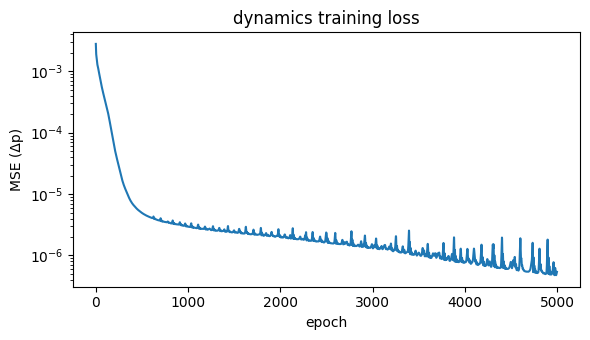

final train MSE: 5.41e-07


In [6]:
H = 10                       # 预测未来 10 帧
T0 = T - 1 - H               # rollout 起点：第 49 帧（最后 10 帧留给评估）

X, Y = [], []
for k in NAMES:
    c = est_centroids[k]
    for t in range(T0):
        X.append(np.concatenate([c[t], c[t + 1] - c[t]]))     # (p_t, v_t)
        Y.append(c[t + 1] - c[t])                             # Δp_t
X = torch.tensor(np.array(X), dtype=torch.float32)
Y = torch.tensor(np.array(Y), dtype=torch.float32)
print(f"training pairs: {len(X)}  ({len(NAMES)} objects × {T0} transitions)")

dyn = DynamicsMLP(hidden=32)
opt = torch.optim.Adam(dyn.parameters(), lr=1e-3)
losses = []
for epoch in range(5000):
    opt.zero_grad()
    loss = ((dyn(X[:, :3], X[:, 3:]) - Y) ** 2).mean()
    loss.backward()
    opt.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 3.5))
plt.plot(losses)
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("MSE (Δp)")
plt.title("dynamics training loss")
plt.tight_layout()
plt.savefig("assets/training_loss.png", dpi=90, bbox_inches="tight")
plt.show()
print(f"final train MSE: {losses[-1]:.2e}")


## 6. Visualize — 让世界动起来

先看原始观测序列的动画：60 帧带噪点云，相机缓慢环绕。注意三个物体的运动个性——cube 边走边转、sphere 绕圈、blob 原地呼吸。

In [7]:
def fig_to_array(fig, dpi=70):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi)
    buf.seek(0)
    img = imageio.imread(buf)
    plt.close(fig)
    return img

all_pts = np.concatenate([np.concatenate([f[k] for k in NAMES]) for f in gt_frames])
lo, hi = all_pts.min(0) - 0.2, all_pts.max(0) + 0.2

def draw_scene(ax, clouds, title="", alpha=0.9):
    for k in NAMES:
        pts = clouds[k]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c=COLORS[k], alpha=alpha)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect((1, 1, 0.8))
    ax.set_title(title)

frames = []
for t in range(T):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    draw_scene(ax, obs_frames[t], title=f"dynamic scene · t = {t:02d}")
    ax.view_init(elev=20, azim=-60 + t)          # 相机缓慢环绕
    frames.append(fig_to_array(fig))

imageio.mimsave("assets/dynamic_scene.gif", frames, duration=0.12, loop=0)
print("saved assets/dynamic_scene.gif  |", len(frames), "frames")


saved assets/dynamic_scene.gif  | 60 frames


### 6.1 Temporal interpolation：在两帧之间"无中生有"

**Why:** 传感器只有离散帧率，但世界是连续的。有了 Section 4 估计的 scene flow，假设帧间运动是**匀速**的，就能合成任意中间时刻：

$$\hat{x}(t + \alpha) = x(t) + \alpha \cdot \text{flow}_i, \qquad \alpha \in [0, 1]$$

这是 D-NeRF / 4D-GS 能在任意时刻 $t$ 查询场景的玩具版——它们用可学的形变场 $\Delta_\psi(x, t)$ 替换了这里的线性近似。我们取第 10、11 帧之间插出 4 个中间时刻（$\alpha = 0.2, 0.4, 0.6, 0.8$），把 1 步变成 6 帧的慢动作。

In [8]:
t_pair = 10
flows = {k: scene_flow(obs_frames[t_pair][k], obs_frames[t_pair + 1][k]) for k in NAMES}
ALPHAS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

frames = []
for a in ALPHAS:
    interp = {k: obs_frames[t_pair][k] + a * flows[k] for k in NAMES}
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    label = f"t = {t_pair}" if a == 0 else (f"t = {t_pair + 1}" if a == 1 else f"t = {t_pair}+{a:.1f} (interpolated)")
    draw_scene(ax, interp, title=label)
    ax.view_init(elev=20, azim=-45)
    frames.append(fig_to_array(fig))

imageio.mimsave("assets/interpolation.gif", frames, duration=0.35, loop=0)
print("saved assets/interpolation.gif | 6 frames: 2 real + 4 synthesized in-between")

# 数值 sanity check：α=1 的插值应与真实第 11 帧重合（误差 = flow 匹配误差）
err = {k: float(np.linalg.norm(obs_frames[t_pair][k] + flows[k] - obs_frames[t_pair + 1][k], axis=1).mean())
       for k in NAMES}
print("interpolation error at α=1 (mean per-point distance to real next frame):",
      {k: round(v, 4) for k, v in err.items()})


saved assets/interpolation.gif | 6 frames: 2 real + 4 synthesized in-between
interpolation error at α=1 (mean per-point distance to real next frame): {'cube': 0.0293, 'sphere': 0.104, 'blob': 0.067}


## 7. Evaluate — 预测未来 10 帧

**Why:** 这是整个实验的落点，也是 world model 概念在 3D 空间的直接形态：站在第 49 帧，只给模型当前状态 $(p_{49}, v_{49})$，让它 **open-loop 外推未来 10 帧**（第 50–59 帧），再与 ground truth 对比。

- 指标：**ADE**（Average Displacement Error，10 步平均位置误差）与 **FDE**（Final Displacement Error，最后一步误差）——轨迹预测领域的标准指标。
- 预期剧情：cube 上 CV 零参数模型接近完美（恒速世界配恒速模型）；sphere 的圆周运动上 CV 的误差随 horizon 爆炸，MLP 学到的向心加速度开始展现价值。
- 也请看 MLP 在 cube 上的表现——它会暴露 learned dynamics 的经典软肋，Section 9 会讨论。

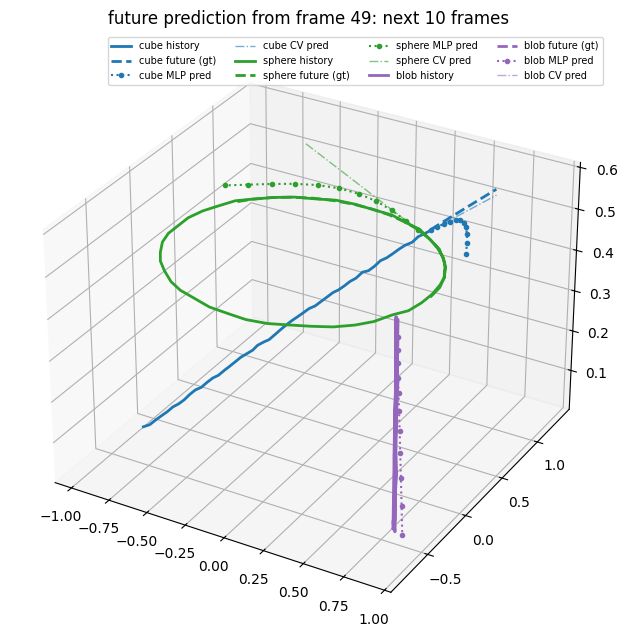

object   model      ADE      FDE
cube     CV     0.0088   0.0143
cube     MLP    0.0713   0.2240
sphere   CV     0.3586   0.8940
sphere   MLP    0.0800   0.1629
blob     CV     0.1528   0.1547
blob     MLP    0.1117   0.1204


In [9]:
pred_mlp, pred_cv = {}, {}
for k in NAMES:
    c = est_centroids[k]
    p0, v0 = c[T0], c[T0] - c[T0 - 1]
    pred_mlp[k] = rollout(dyn, p0, v0, H)
    pred_cv[k]  = rollout(cv_step, p0, v0, H)

fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(111, projection="3d")
for k in NAMES:
    hist = est_centroids[k][:T0 + 1]
    fut  = gt_centroids[k][T0:T0 + H + 1]
    ax.plot(hist[:, 0], hist[:, 1], hist[:, 2], c=COLORS[k], lw=2, label=f"{k} history")
    ax.plot(fut[:, 0], fut[:, 1], fut[:, 2], c=COLORS[k], lw=2, ls="--", label=f"{k} future (gt)")
    ax.plot(pred_mlp[k][:, 0], pred_mlp[k][:, 1], pred_mlp[k][:, 2], c=COLORS[k], lw=1.5, ls=":", marker=".", label=f"{k} MLP pred")
    ax.plot(pred_cv[k][:, 0], pred_cv[k][:, 1], pred_cv[k][:, 2], c=COLORS[k], lw=1, ls="-.", alpha=0.6, label=f"{k} CV pred")
ax.legend(fontsize=7, ncol=4)
ax.set_title(f"future prediction from frame {T0}: next {H} frames")
plt.tight_layout()
plt.savefig("assets/future_trajectories.png", dpi=90, bbox_inches="tight")
plt.show()

print(f"{'object':8s} {'model':4s} {'ADE':>8s} {'FDE':>8s}")
for k in NAMES:
    g = gt_centroids[k][T0 + 1:T0 + H + 1]
    for name, pr in [("CV", pred_cv[k]), ("MLP", pred_mlp[k])]:
        e = np.linalg.norm(pr[1:] - g, axis=1)
        print(f"{k:8s} {name:4s} {e.mean():8.4f} {e[-1]:8.4f}")


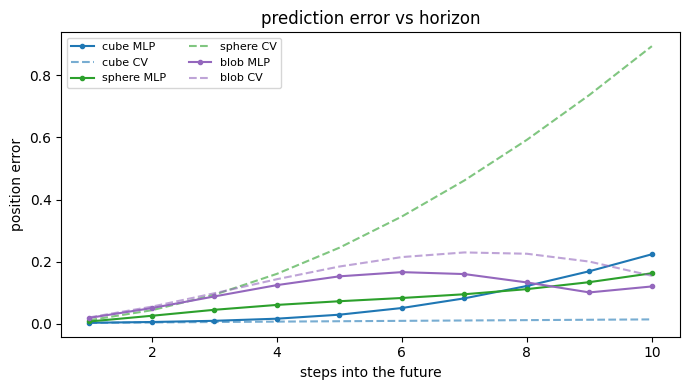

saved assets/prediction.gif | 11 frames
total notebook time so far: 4.4 s


In [10]:
# --- 逐帧误差曲线：误差如何随 horizon 增长 ---
plt.figure(figsize=(7, 4))
for k in NAMES:
    g = gt_centroids[k][T0 + 1:T0 + H + 1]
    e_mlp = np.linalg.norm(pred_mlp[k][1:] - g, axis=1)
    e_cv  = np.linalg.norm(pred_cv[k][1:] - g, axis=1)
    plt.plot(range(1, H + 1), e_mlp, c=COLORS[k], ls="-", marker="o", ms=3, label=f"{k} MLP")
    plt.plot(range(1, H + 1), e_cv, c=COLORS[k], ls="--", alpha=0.6, label=f"{k} CV")
plt.xlabel("steps into the future"); plt.ylabel("position error")
plt.title("prediction error vs horizon"); plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("assets/prediction_error.png", dpi=90, bbox_inches="tight")
plt.show()

# --- predicted vs actual：把预测的质心运动施加到最后观测的点云上（刚性假设） ---
frames = []
for k_step in range(H + 1):
    t = T0 + k_step
    shifted = {k: obs_frames[T0][k] + (pred_mlp[k][k_step] - est_centroids[k][T0]) for k in NAMES}
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    for k in NAMES:   # actual
        pts = obs_frames[t][k]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c=COLORS[k], alpha=0.9, label=f"{k} actual")
    for k in NAMES:   # predicted
        pts = shifted[k]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c="red", alpha=0.35, marker="x")
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect((1, 1, 0.8))
    ax.scatter([], [], [], c="red", marker="x", label="predicted (MLP)")
    ax.legend(fontsize=7, loc="upper left")
    ax.set_title(f"predicted vs actual · t = {t}")
    ax.view_init(elev=20, azim=-45)
    frames.append(fig_to_array(fig))

imageio.mimsave("assets/prediction.gif", frames, duration=0.35, loop=0)
print("saved assets/prediction.gif |", len(frames), "frames")
print(f"total notebook time so far: {time.time() - T_CLOCK:.1f} s")


## 8. Experiment

### ✏️ Exercise 1 — 非刚性形变更剧烈会怎样？

把 `BREATH_AMP` 从 0.3 调到 0.8、`BREATH_OMEGA` 从 0.35 调到 0.8，重跑 Section 3 之后的所有 cell。观察：

1. blob 的 scene flow 箭头还规则吗？
2. 质心 tracking 受不受影响？为什么形变对质心"平均而言"影响小？
3. prediction GIF 里红色预测点云（刚性平移假设）与蓝色实际的 blob 差距变大了吗？

**Hint:** 只需改 Section 3 的两个常量并重跑；想想"刚性平移 + 质心动力学"这套管线里哪一环最先被非刚性形变打破。

In [11]:
# YOUR CODE HERE
# hint: BREATH_AMP, BREATH_OMEGA = 0.8, 0.8，然后重跑 Section 3–7
pass


### ✏️ Exercise 2 — 多物体遮挡与丢点

真实深度相机有遮挡：物体互相挡住时，被挡部分该帧**完全没有观测**。修改观测生成代码：每帧对每个物体随机丢掉 30% 的点（`obs = pts[rng.choice(len(pts), size=int(0.7*len(pts)), replace=False)]`），或者更进一步，让 sphere 转到 cube 后方时按视线深度剔除被挡点。重跑后回答：

1. centroid tracking 误差变大多少？（提示：随机丢点不偏，但**遮挡丢点是有偏的**——被挡的总是同一侧）
2. ICP 的旋转估计误差如何变化？最近邻匹配在稀疏点云上为何更脆弱？
3. 这对应模块 05 讲的哪个概念？（observability / 观测不足）

In [12]:
# YOUR CODE HERE
# hint: 在 obs_frames 生成处加随机丢点；有偏遮挡可沿 -y 方向看，按点深度排序剔除
pass


### ✏️ Exercise 3 — 预测 horizon 的极限

把 `H` 改成 5 和 20 分别重跑 Section 5–7（注意 `T0` 会自动跟着变），把两条 ADE/FDE 曲线画在一起：

1. 哪个模型对 horizon 更敏感，MLP 还是 CV？
2. H = 20 时 sphere 的 MLP 误差曲线是什么形状——单调上升还是有结构？（想想圆周运动的周期性）
3. 结合 Lab 2 的 drift 曲线：open-loop 外推误差增长的两个来源是什么？怎样用观测校正（呼应 Lab 1 Kalman filter 的 update 步）？

**Hint:** 只改 `H` 一个常量；第 2 问提示：圆周运动的预测误差理论上以轨道直径为上界。

In [13]:
# YOUR CODE HERE
# hint: H = 5 / 20，重跑 Section 5–7，对比 ADE/FDE
pass


## 9. Questions

1. **静态表示的根本缺陷**：为什么一张再精确的静态点云 $(x, y, z)$ 在原理上无法回答"下一秒在哪里"？它缺的是哪一类状态变量？
2. **最近邻匹配的失效条件**：scene flow 的 NN 对应在什么情况下会错配？（至少说出：帧间位移 vs 点间距、重复/对称结构、密度不均。）真实的 scene flow 方法（如 FlowNet3D、NSFP）用什么替代硬匹配？
3. **CV 为什么赢了 cube**：constant-velocity 在 cube 上优于学了 5000 轮的 MLP。这暴露了 learned dynamics 的什么弱点（提示：rollout 时 $(p, v)$ 离开了训练分布）？这个发现对"什么时候该学模型、什么时候该用手写先验"有什么启示？
4. **从线性插值到形变场**：我们的 temporal interpolation 假设帧间匀速直线运动。D-NeRF / 4D-GS 的 canonical space + deformation field 范式为什么更通用？它回答"任意时刻 $t$ 的世界"的方式与我们有何本质不同？

## 10. Takeaways

- **4D = 3D + time**：静态点云 $(x,y,z)$ 是快照，4D 表示 $(x,y,z,t)$ 把运动与历史变成表示的一等公民——它是 spatial world model 的动态扩展，也是从"重建照片"走向"建模世界"的一步。
- **运动估计**把帧序列变成动力学原料：centroid tracking 给出 object-level 平移，手写的 ICP-style 配准（NN 匹配 + Kabsch/SVD 迭代）恢复刚性位姿，scene flow 给出逐点运动场。NN 匹配在帧间位移小于点间距时相当可靠（本实验 ICP 旋转误差 ~1°）。
- **Temporal interpolation** 是 flow 的直接红利：$x(t+\alpha) = x(t) + \alpha\cdot\text{flow}$ 能在两帧之间合成慢动作——真实 4D 表示（D-NeRF、4D-GS）用可学形变场把这件事推广到任意时刻与任意视角。
- **Future prediction 是 world model 在 3D 空间的形态**：MLP dynamics 在圆周/正弦运动上显著优于恒速先验；但在恒速直线运动上，零参数的 CV 反而更准——learned model 在训练分布之外的外推没有保证，open-loop 误差随 horizon 复涨（与 Lab 2 的 drift 完全同构）。
- 静态表示无法回答"下一秒在哪里"；要让空间表示成为 world model，必须显式建模时间维度上的状态演化。

**Next**：模块 06 State Estimation（[/docs/spatial/06-state-estimation](https://github.com/overdued/world-model-spatial-intelligence-course/blob/main/website/docs/spatial/06-state-estimation.mdx)）——当有噪声的观测不断到来时，如何把"预测"与"校正"交替进行（正是 Lab 1 Kalman filter 在 3D tracking 里的样子）。

*Course: World Models & Spatial Intelligence. Related: DynamicFusion (2015); D-NeRF (2021); 4D Gaussian Splatting (2024); FlowNet3D (2018).*